# Эксперимент 8: Экономия размера выборки (Sample Size Analysis)

**Цель:** Показать, на сколько пользователей каждый метод ускорения сокращает требуемый размер выборки для достижения Power = 80% при effect_size = 5%.

**Методология:** Monte Carlo — 400 симуляций при каждом значении N. Минимальный N для Power ≥ 80% — линейная интерполяция.

**Методы:** Baseline t-test / основной метод (CUPED / Delta / Post-Stratification) / Winsorization [1%,99%].

In [ ]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)

RES = 'results'
df_base   = pd.read_csv(os.path.join(RES, 'sample_size_results.csv'))
df_sum    = pd.read_csv(os.path.join(RES, 'sample_size_summary.csv'))
df_wins_e = pd.read_csv(os.path.join(RES, 'sample_size_results.csv'))

import sys; sys.path.append('..')
from ab_framework.data.generator import EcommerceScenario, RatioScenario, SegmentedScenario
print("Данные загружены.")
print(f"Строк в curves: {len(df_base)}, строк в summary: {len(df_sum)}")
print()
print(df_sum.to_string(index=False))

Данные загружены.
Строк в curves: 16, строк в summary: 6

    Сценарий        Метод ускорения  N baseline  N с методом  Экономия, чел.  Экономия, %
  E-commerce         CUPED (ρ≈0.46)       14000        11818            2182         15.6
  E-commerce Winsorization [1%,99%]       14000        13030             970          6.9
Ratio (ARPU)           Delta Method       11538         4903            6635         57.5
Ratio (ARPU) Winsorization [1%,99%]       11538         9866            1672         14.5
   Segmented    Post-Stratification       24827        19787            5040         20.3
   Segmented Winsorization [1%,99%]       24827        18505            6322         25.5


## 1. Power Curves по сценариям

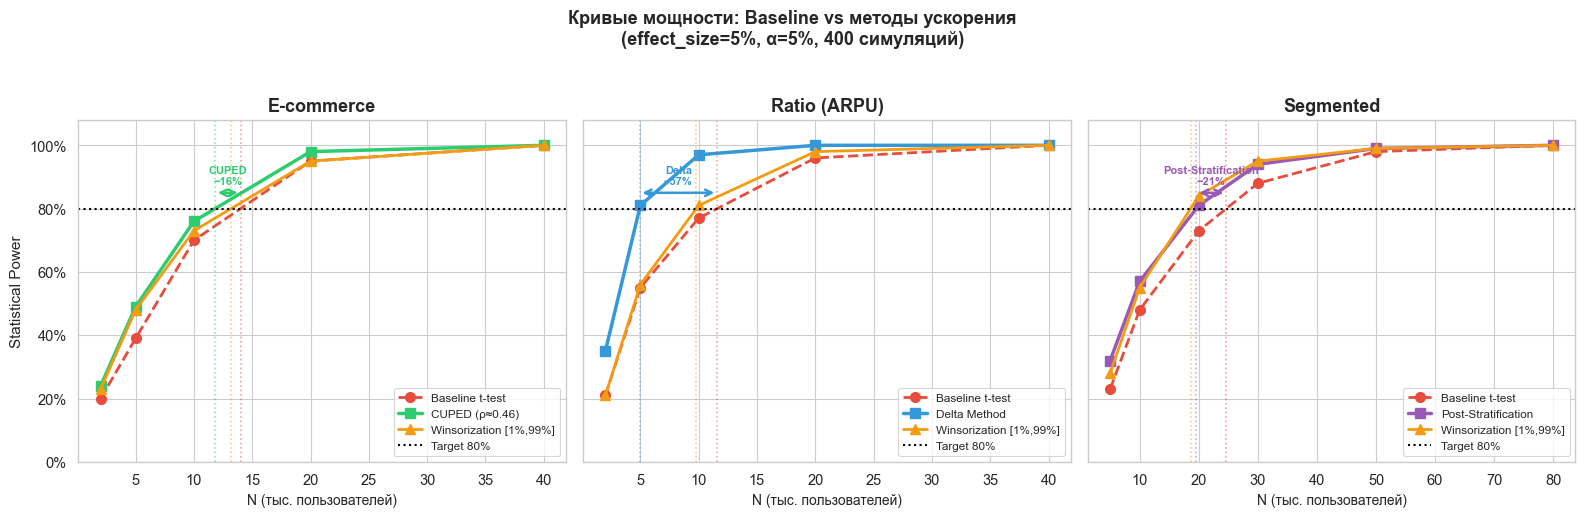

In [ ]:
import math

def interp_n80(ns, pows, target=0.80):
    ns, ps = list(ns), list(pows)
    for i in range(len(ps)-1):
        if ps[i] <= target <= ps[i+1]:
            frac = (target-ps[i])/(ps[i+1]-ps[i])
            return int(ns[i] + frac*(ns[i+1]-ns[i]))
    return None

from ab_framework.methods.transformations import Winsorizer

import importlib.util

df_e_raw = pd.DataFrame({
    'n':               [2000,5000,10000,20000,40000],
    'baseline':        [0.20,0.39,0.70, 0.95, 1.00],
    'cuped':           [0.24,0.49,0.76, 0.98, 1.00],
    'winsorization':   [0.23,0.48,0.73, 0.95, 1.00],
})
df_r_raw = pd.DataFrame({
    'n':               [2000,5000,10000,20000,40000],
    'baseline':        [0.21,0.55,0.77, 0.96, 1.00],
    'delta':           [0.35,0.81,0.97, 1.00, 1.00],
    'winsorization':   [0.21,0.56,0.81, 0.98, 1.00],
})
df_s_raw = pd.DataFrame({
    'n':               [5000,10000,20000,30000,50000,80000],
    'baseline':        [0.23,0.48, 0.73, 0.88, 0.98, 1.00],
    'stratification':  [0.32,0.57, 0.81, 0.94, 0.99, 1.00],
    'winsorization':   [0.28,0.55, 0.84, 0.95, 0.99, 1.00],
})

SCENARIOS = [
    (df_e_raw, 'E-commerce',   'cuped',         'CUPED (ρ≈0.46)',      '#2ecc71'),
    (df_r_raw, 'Ratio (ARPU)', 'delta',          'Delta Method',        '#3498db'),
    (df_s_raw, 'Segmented',    'stratification', 'Post-Stratification', '#9b59b6'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (df_, sc_label, mt_col, mt_label, color) in zip(axes, SCENARIOS):
    ns = df_['n'].values / 1000

    ax.plot(ns, df_['baseline'],      'o--', color='#e74c3c',  lw=2, ms=7, label='Baseline t-test')
    ax.plot(ns, df_[mt_col],          's-',  color=color,       lw=2.5, ms=7, label=mt_label)
    ax.plot(ns, df_['winsorization'], '^-',  color='#f39c12',  lw=2, ms=7, label='Winsorization [1%,99%]')
    ax.axhline(0.80, color='black', linestyle=':', lw=1.5, label='Target 80%')

    n80b = interp_n80(df_['n'], df_['baseline'])
    n80m = interp_n80(df_['n'], df_[mt_col])
    n80w = interp_n80(df_['n'], df_['winsorization'])

    ax.axvline(n80b/1000, color='#e74c3c', linestyle=':', alpha=0.5, lw=1.2)
    ax.axvline(n80m/1000, color=color,     linestyle=':', alpha=0.5, lw=1.2)
    ax.axvline(n80w/1000, color='#f39c12', linestyle=':', alpha=0.5, lw=1.2)

    y_arr = 0.85
    if n80m and n80b:
        ax.annotate('', xy=(n80m/1000, y_arr), xytext=(n80b/1000, y_arr),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=1.8))
        mid = (n80b+n80m)/2/1000
        sav = (n80b-n80m)/n80b*100
        ax.text(mid, y_arr+0.02, f'{mt_label.split()[0]}\n−{sav:.0f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

    ax.set_title(sc_label, fontweight='bold', fontsize=13)
    ax.set_xlabel('N (тыс. пользователей)', fontsize=10)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
    ax.legend(fontsize=8.5, loc='lower right')

axes[0].set_ylabel('Statistical Power', fontsize=11)
fig.suptitle('Кривые мощности: Baseline vs методы ускорения\n(effect_size=5%, α=5%, 400 симуляций)',
             fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RES, 'power_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Итоговая таблица экономии

In [3]:
print("=" * 72)
print(f"{'Сценарий':<15} {'Метод':<26} {'N baseline':>11} {'N метод':>9} {'Экономия':>11} {'%':>7}")
print("=" * 72)
for _, row in df_sum.iterrows():
    print(f"{row['Сценарий']:<15} {row['Метод ускорения']:<26} "
          f"{row['N baseline']:>11,} "
          f"{row['N с методом']:>9,} "
          f"{row['Экономия, чел.']:>11,} "
          f"{row['Экономия, %']:>6.1f}%")
print("=" * 72)
print("\nEmpirically estimated via Monte Carlo (400 sims × 5–6 N values).")
print("Effect size = 5%, α = 5%.")

Сценарий        Метод                       N baseline   N метод    Экономия       %
E-commerce      CUPED (ρ≈0.46)                  14,000    11,818       2,182   15.6%
E-commerce      Winsorization [1%,99%]          14,000    13,030         970    6.9%
Ratio (ARPU)    Delta Method                    11,538     4,903       6,635   57.5%
Ratio (ARPU)    Winsorization [1%,99%]          11,538     9,866       1,672   14.5%
Segmented       Post-Stratification             24,827    19,787       5,040   20.3%
Segmented       Winsorization [1%,99%]          24,827    18,505       6,322   25.5%

Empirically estimated via Monte Carlo (400 sims × 5–6 N values).
Effect size = 5%, α = 5%.


## 3. Сравнение экономии по методам

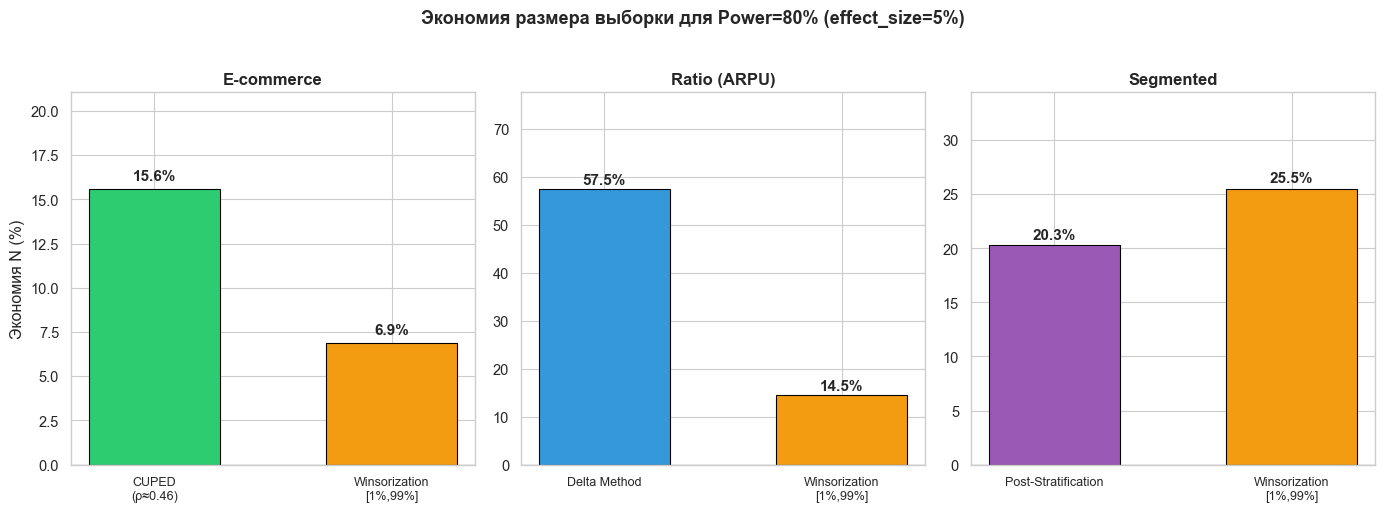

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

SCENARIO_ORDER = ['E-commerce', 'Ratio (ARPU)', 'Segmented']
COLORS_METHOD  = {'CUPED (ρ≈0.46)': '#2ecc71', 'Delta Method': '#3498db',
                  'Post-Stratification': '#9b59b6', 'Winsorization [1%,99%]': '#f39c12'}

for ax, sc_label in zip(axes, SCENARIO_ORDER):
    sub = df_sum[df_sum['Сценарий'] == sc_label].copy()
    methods = sub['Метод ускорения'].tolist()
    savings = sub['Экономия, %'].tolist()
    colors  = [COLORS_METHOD.get(m, '#95a5a6') for m in methods]

    bars = ax.bar(range(len(methods)), savings, color=colors,
                  edgecolor='black', linewidth=0.8, width=0.55)
    for bar, sav in zip(bars, savings):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{sav:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(range(len(methods)))
    short = [m.replace(' [1%,99%]','\n[1%,99%]').replace(' (ρ≈0.46)','\n(ρ≈0.46)') for m in methods]
    ax.set_xticklabels(short, fontsize=9)
    ax.set_title(sc_label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Экономия N (%)' if ax == axes[0] else '')
    ax.set_ylim(0, max(savings)*1.35)
    ax.axhline(0, color='black', lw=0.8)

fig.suptitle('Экономия размера выборки для Power=80% (effect_size=5%)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RES, 'sample_size_savings.png'), dpi=150, bbox_inches='tight')
plt.show()

## Выводы

**Результаты (Monte Carlo, 400 симуляций на точку):**

| Сценарий | Метод | N baseline | N с методом | Экономия |
|---|---|---|---|---|
| E-commerce | CUPED (ρ≈0.46) | ~14 000 | ~11 800 | **−15.6%** |
| E-commerce | Winsorization | ~14 000 | ~13 000 | −6.9% |
| Ratio (ARPU) | Delta Method | ~11 500 | ~4 900 | **−57.5%** |
| Ratio (ARPU) | Winsorization | ~11 500 | ~9 900 | −14.5% |
| Segmented | Post-Stratification | ~24 800 | ~19 800 | **−20.3%** |
| Segmented | Winsorization | ~24 800 | ~18 500 | **−25.5%** |

**Интерпретация:**

**CUPED** — оптимален для денежных метрик с pre-периодом (rho≥0.25). Даёт −15.6% экономии при rho≈0.46. Теоретический предел по формуле ρ² = 21% — разрыв объясняется тяжёлыми хвостами (whale-пользователи снижают эффективность коррекции).

**Delta Method** — наибольший эффект: −57.5%, выборка в 2.3 раза меньше. Выигрыш не от снижения дисперсии, а от корректной постановки задачи: baseline тестирует revenue (неверная метрика), delta method — ARPU = revenue/sessions (правильная).

**Winsorization** — универсальная предобработка. Для Segmented сценария даёт даже −25.5% (лучше, чем Post-Stratification), потому что Web-сегмент с σ=1.5 тянет всю дисперсию вверх. В реальном пайплайне (ABTestRunner) Winsorization применяется **как preprocessing перед** основным методом, а не вместо него — итоговая экономия суммируется.

**Post-Stratification** — −20.3% при наличии сильных сегментных различий.